<a href="https://colab.research.google.com/github/malek-lab/IA_GEN/blob/main/TP_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP M2 DataScience : Variational Auto-Encoder (VAE)
## 2025-2026

**Théorie — Modèle génératif VAE :**

Un VAE (Kingma & Welling, 2013) suppose que les données $x$ sont générées par une variable latente $z$ :
$$p_\theta(x) = \int p_\theta(x|z)\, p(z)\, dz$$

où $p(z) = \mathcal{N}(0, I)$ est un a priori simple. Le problème : cette intégrale est intractable.

**Solution — ELBO (Evidence Lower BOund) :**

On introduit un encodeur $q_\phi(z|x)$ qui approche la vraie posterior $p(z|x)$. Par l'inégalité de Jensen :
$$\log p_\theta(x) \geq \underbrace{\mathbb{E}_{z \sim q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{terme de reconstruction}} - \underbrace{KL(q_\phi(z|x) \| p(z))}_{\text{terme de régularisation}}$$

On maximise cette borne inférieure (ELBO) au lieu de la log-vraisemblance directe :
- **Terme de reconstruction** : l encodeur compresse $x$ en $z$, le décodeur reconstruit $x$ depuis $z$. Favorise la fidélité de reconstruction.
- **Terme KL** : force $q_\phi(z|x)$ à rester proche de $\mathcal{N}(0,I)$. Régularise l espace latent et permet la génération (on peut sampler $z \sim \mathcal{N}(0,I)$ directement).

**Reparametrization trick :**

Le tirage $z \sim q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2 I)$ est stochastique, donc non-différentiable. On réécrit :
$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$
Le bruit $\epsilon$ n est plus paramétrisé, donc les gradients passent à travers $\mu$ et $\sigma$.

**KL-divergence analytique :**

Pour $q_\phi(z|x) = \mathcal{N}(\mu, \text{diag}(\sigma^2))$ et $p(z) = \mathcal{N}(0, I)$, la KL est calculable analytiquement. En paramètrisant $\text{logsigma} = \log(\sigma^2)$ pour la stabilité numérique :
$$KL(q_\phi(z|x) \| p(z)) = -\frac{1}{2} \sum_{i=1}^{d} \left(1 + \text{logsigma}_i - \mu_i^2 - e^{\text{logsigma}_i}\right)$$

## Configuration et imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print(f"PyTorch : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")

PyTorch : 2.10.0+cu128
Device  : cuda


## Chargement de MNIST

**Théorie — Preprocessing :**

Pour un VAE avec décodeur Bernoulli, les images doivent être dans $[0, 1]$ (les paramètres d une bernoulli sont des probabilités). On utilise :
- `ToTensor()` : uint8 [0,255] -> float32 [0,1], shape (1, 28, 28)
- Pas de normalisation en [-1,1] contrairement au GAN, car la Sigmoid du décodeur produit des sorties dans [0,1], cohérentes avec BCE.

La BCE (Binary Cross-Entropy) sert de terme de reconstruction car chaque pixel est modélisé par une Bernoulli indépendante :
$$-\log p_\theta(x|z) = -\sum_j \left[x_j \log(\hat{x}_j) + (1-x_j) \log(1-\hat{x}_j)\right]$$

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.63MB/s]

Train : 60000 images | Test : 10000 images


Shape d un batch : torch.Size([128, 1, 28, 28])


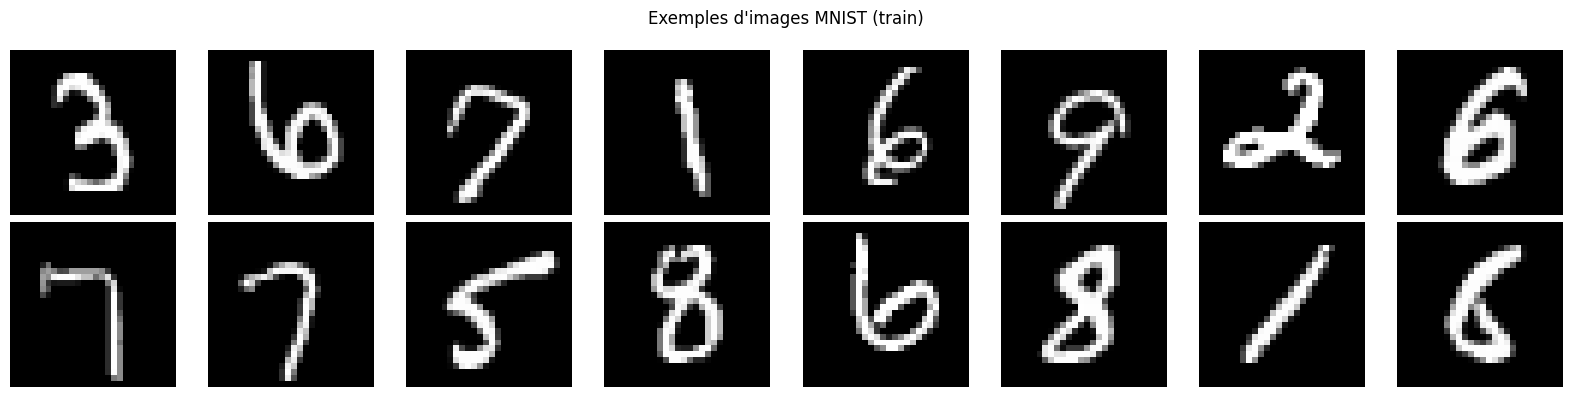

In [ ]:
# MNIST : 60K images d'entraînement + 10K de test, 1 canal gris, 28x28 pixels
# Valeurs dans [0,1] : cohérent avec la Sigmoid du décodeur (bernoulli par pixel)
transform = transforms.Compose([
    transforms.ToTensor(),   # [0,255] uint8 -> [0,1] float32, shape (1,28,28)
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train : {len(train_dataset)} images | Test : {len(test_dataset)} images")
print(f"Shape d un batch : {next(iter(train_loader))[0].shape}")

# Affichage de quelques images réelles
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
sample_imgs = next(iter(train_loader))[0][:16]
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Exemples d'images MNIST (train)")
plt.tight_layout()
plt.show()

## Partie 1 : VAE avec architecture MLP (fully connected)

**Architecture :**

**Encodeur** : Linear(784->256) -> ReLU -> Linear(256->2*latent_dim)
La dernière couche produit deux vecteurs concaténés : $[\mu, \text{logsigma}]$ de taille $2d$.

**Décodeur** : Linear(latent_dim->256) -> ReLU -> Linear(256->784) -> Sigmoid
La Sigmoid garantit une sortie dans $[0,1]$ interprétable comme paramètre de Bernoulli par pixel.

**Pourquoi logsigma et non sigma ?**
- $\sigma^2 > 0$ toujours, mais un réseau peut produire n importe quelle valeur réelle.
- En prédisant $\log(\sigma^2) \in \mathbb{R}$, pas de contrainte de signe à gérer.
- $\sigma^2 = e^{\text{logsigma}}$ est toujours positif par définition.
- Numériquement plus stable : évite les valeurs proches de 0 ou très grandes.

In [ ]:
class VAE_MLP(nn.Module):
    def __init__(self, latent_dim=2):
        # VAE avec encodeur et décodeur fully-connected (MLP).
        # latent_dim : dimension de l espace latent z.
        # 2 permet la visualisation 2D directe.
        # Plus grande -> meilleure reconstruction, espace moins interprétable.
        super(VAE_MLP, self).__init__()
        self.latent_dim = latent_dim

        # ── Encodeur q_phi(z|x) ────────────────────────────────────────────
        # Prend une image x aplatie (784) et produit les paramètres de N(mu, sigma)
        self.encoder_fc1 = nn.Linear(784, 256)    # couche intermédiaire
        # La dernière couche produit mu ET logsigma simultanément (2*latent_dim sorties)
        # On splitte ensuite : fc2[:, :latent_dim] = mu, fc2[:, latent_dim:] = logsigma
        self.encoder_fc2 = nn.Linear(256, 2 * latent_dim)

        # ── Décodeur p_theta(x|z) ──────────────────────────────────────────
        # Prend un vecteur latent z (obtenu par reparametrization) et reconstruit x
        self.decoder_fc1 = nn.Linear(latent_dim, 256)
        self.decoder_fc2 = nn.Linear(256, 784)    # 784 = 28*28 pixels

    def encode(self, x):
        # Encodeur : x -> (mu, logsigma)
        # x : (batch, 1, 28, 28) ou (batch, 784)
        # Retourne mu et logsigma, chacun de taille (batch, latent_dim).
        x = x.view(x.size(0), -1)            # aplatir : (batch, 784)
        h = F.relu(self.encoder_fc1(x))      # (batch, 256)
        out = self.encoder_fc2(h)             # (batch, 2*latent_dim)
        mu       = out[:, :self.latent_dim]   # (batch, latent_dim) : moyennes
        logsigma = out[:, self.latent_dim:]   # (batch, latent_dim) : log(sigma^2)
        return mu, logsigma

    def reparametrize(self, mu, logsigma):
        # Reparametrization trick : z = mu + sigma * epsilon, epsilon ~ N(0, I)
        # Permet la backpropagation à travers le tirage stochastique :
        # - Sans trick : z ~ N(mu, sigma) est non-différentiable par rapport à mu, sigma
        # - Avec trick : le bruit epsilon est non-paramétrisé -> gradient passe dans mu, sigma
        # En mode eval (génération), on peut aussi utiliser directement mu (pas de bruit)
        # ou sampler normalement.
        if self.training:
            # sigma = sqrt(sigma^2) = exp(logsigma / 2)
            # logsigma = log(sigma^2), donc sigma = exp(logsigma/2)
            std = torch.exp(0.5 * logsigma)           # (batch, latent_dim)
            epsilon = torch.randn_like(std)            # epsilon ~ N(0,I), même shape
            return mu + std * epsilon                  # z = mu + sigma * epsilon
        else:
            # En eval, on retourne directement mu (décodage déterministe, meilleure reconstruction)
            return mu

    def decode(self, z):
        # Décodeur : z -> x_reconstructed (paramètres des bernoulli, dans [0,1])
        # z : (batch, latent_dim)
        # Retourne x_hat : (batch, 784) valeurs dans [0,1]
        h = F.relu(self.decoder_fc1(z))      # (batch, 256)
        # Sigmoid : garantit sortie dans [0,1] = paramètre de bernoulli par pixel
        x_hat = torch.sigmoid(self.decoder_fc2(h))  # (batch, 784)
        return x_hat

    def forward(self, x):
        # Passe complète : x -> encode -> reparametrize -> decode -> x_hat
        # Retourne x_hat, mu, logsigma pour le calcul de la loss.
        mu, logsigma = self.encode(x)
        z     = self.reparametrize(mu, logsigma)
        x_hat = self.decode(z)
        return x_hat, mu, logsigma


def vae_loss(x, x_hat, mu, logsigma):
    # Loss totale du VAE = -ELBO = reconstruction_loss + kl_loss
    # reconstruction_loss : Binary Cross-Entropy par pixel
    # BCE(x, x_hat) = -sum_j [x_j*log(x_hat_j) + (1-x_j)*log(1-x_hat_j)]
    # Modélise chaque pixel comme une bernoulli de paramètre x_hat_j.
    # reduction='sum' : somme sur tous les pixels du batch (pas moyenne)
    # -> comparable à la KL qui est aussi une somme
    # kl_loss : KL analytique entre N(mu, diag(exp(logsigma))) et N(0, I)
    # KL = -1/2 * sum_i (1 + logsigma_i - mu_i^2 - exp(logsigma_i))
    # Cette formule est dérivée de la KL entre deux gaussiennes et utilise
    # exp(logsigma) = sigma^2 directement.
    # Un KL=0 signifie q_phi(z|x) = p(z) (encodeur qui ignore x -> espace latent standard)
    # Un KL grand signifie que l encodeur s'éloigne de la prior N(0,I)
    # La somme reconstruction + KL est le -ELBO qu'on minimise.
    # Note : en pratique on divise par batch_size pour avoir une loss indépendante du batch.
    batch_size = x.size(0)
    x_flat = x.view(batch_size, -1)  # (batch, 784)

    # Terme de reconstruction : BCE pixel par pixel, sommé sur le batch
    recon_loss = F.binary_cross_entropy(x_hat, x_flat, reduction='sum')

    # Terme KL : -1/2 * sum(1 + logsigma - mu^2 - exp(logsigma))
    # .sum(1) : somme sur les dimensions latentes -> (batch,)
    # .sum()  : somme sur le batch -> scalaire
    kl_loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())

    # Loss totale normalisée par le nombre d'images
    return (recon_loss + kl_loss) / batch_size, recon_loss / batch_size, kl_loss / batch_size


# Test rapide des dimensions
model_test = VAE_MLP(latent_dim=2)
# x_test should contain values between 0 and 1 for binary_cross_entropy
x_test = torch.rand(4, 1, 28, 28)
x_hat, mu, ls = model_test(x_test)
print(f"x       : {tuple(x_test.shape)}")
print(f"x_hat   : {tuple(x_hat.shape)}")
print(f"mu      : {tuple(mu.shape)}")
print(f"logsigma: {tuple(ls.shape)}")
loss, r, k = vae_loss(x_test, x_hat, mu, ls)
print(f"loss={loss.item():.3f}  recon={r.item():.3f}  kl={k.item():.3f}")
print("Dimensions OK")

x       : (4, 1, 28, 28)
x_hat   : (4, 784)
mu      : (4, 2)
logsigma: (4, 2)
loss=551.429  recon=551.416  kl=0.013
Dimensions OK


## Entraînement du VAE MLP

**Théorie — Compromis reconstruction/régularisation :**

La loss VAE est un compromis :
- Reconstruction faible (BCE faible) -> l encodeur peut mapper chaque $x$ sur un $z$ très précis et distinct, mais l espace latent devient fragmenté et inutilisable pour la génération.
- KL faible -> l encodeur est forcé de mapper tous les $x$ proches de $\mathcal{N}(0,I)$, mais la reconstruction peut se dégrader.

A l'équilibre, l espace latent est **continu et structuré** : des $z$ proches correspondent à des $x$ similaires. C'est ce qui distingue le VAE d un auto-encodeur classique.

In [ ]:
def train_vae(model, train_loader, test_loader, n_epochs=20, lr=1e-3):
    # Boucle d'entraînement standard avec logging des courbes loss.
    # Retourne les historiques de loss pour visualisation.
    optimizer = Adam(model.parameters(), lr=lr)
    model = model.to(device)

    history = {'train_loss':[], 'val_loss':[], 'train_recon':[], 'val_recon':[], 'train_kl':[], 'val_kl':[]}

    for epoch in range(n_epochs):
        # ── Phase train ───────────────────────────────────────────────────
        model.train()
        total_loss = total_recon = total_kl = 0.0

        for x, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False):
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, logsigma = model(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, logsigma)
            loss.backward()
            optimizer.step()
            total_loss  += loss.item()
            total_recon += recon.item()
            total_kl    += kl.item()

        n = len(train_loader)
        history['train_loss'].append(total_loss / n)
        history['train_recon'].append(total_recon / n)
        history['train_kl'].append(total_kl / n)

        # ── Phase eval ────────────────────────────────────────────────────
        model.eval()
        total_loss = total_recon = total_kl = 0.0

        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                x_hat, mu, logsigma = model(x)
                loss, recon, kl = vae_loss(x, x_hat, mu, logsigma)
                total_loss  += loss.item()
                total_recon += recon.item()
                total_kl    += kl.item()

        n = len(test_loader)
        history['val_loss'].append(total_loss / n)
        history['val_recon'].append(total_recon / n)
        history['val_kl'].append(total_kl / n)

        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"train loss={history['train_loss'][-1]:.1f}  recon={history['train_recon'][-1]:.1f}  kl={history['train_kl'][-1]:.2f} | "
              f"val loss={history['val_loss'][-1]:.1f}  recon={history['val_recon'][-1]:.1f}  kl={history['val_kl'][-1]:.2f}")

    return history


def plot_loss_curves(history, title=""):
    # Courbes de loss totale, reconstruction et KL pour train et val.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, key, label in zip(axes,
        ['loss', 'recon', 'kl'],
        ['Loss totale (-ELBO)', 'Reconstruction (BCE)', 'Régularisation (KL)']):
        ax.plot(history[f'train_{key}'], label='Train')
        ax.plot(history[f'val_{key}'],   label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(label)
        ax.set_title(f'{label} — {title}'); ax.legend()
    plt.tight_layout(); plt.show()
    # Interprétation :
    # - BCE qui diminue : décodeur qui apprend à reconstruire fidèlement
    # - KL qui augmente au début puis se stabilise : encodeur qui structure l espace latent
    # - Loss val < loss train possible avec VAE car bruit du reparametrization en train seulement

Paramètres : 404,244


Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   1/20 | train loss=195.2  recon=188.9  kl=6.33 | val loss=174.6  recon=169.2  kl=5.36


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   2/20 | train loss=171.3  recon=166.2  kl=5.15 | val loss=166.7  recon=161.6  kl=5.16


...

Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0><function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

         if

Epoch  19/20 | train loss=152.5  recon=146.6  kl=5.86 | val loss=152.2  recon=146.4  kl=5.73


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  20/20 | train loss=152.2  recon=146.3  kl=5.86 | val loss=152.0  recon=146.1  kl=5.85


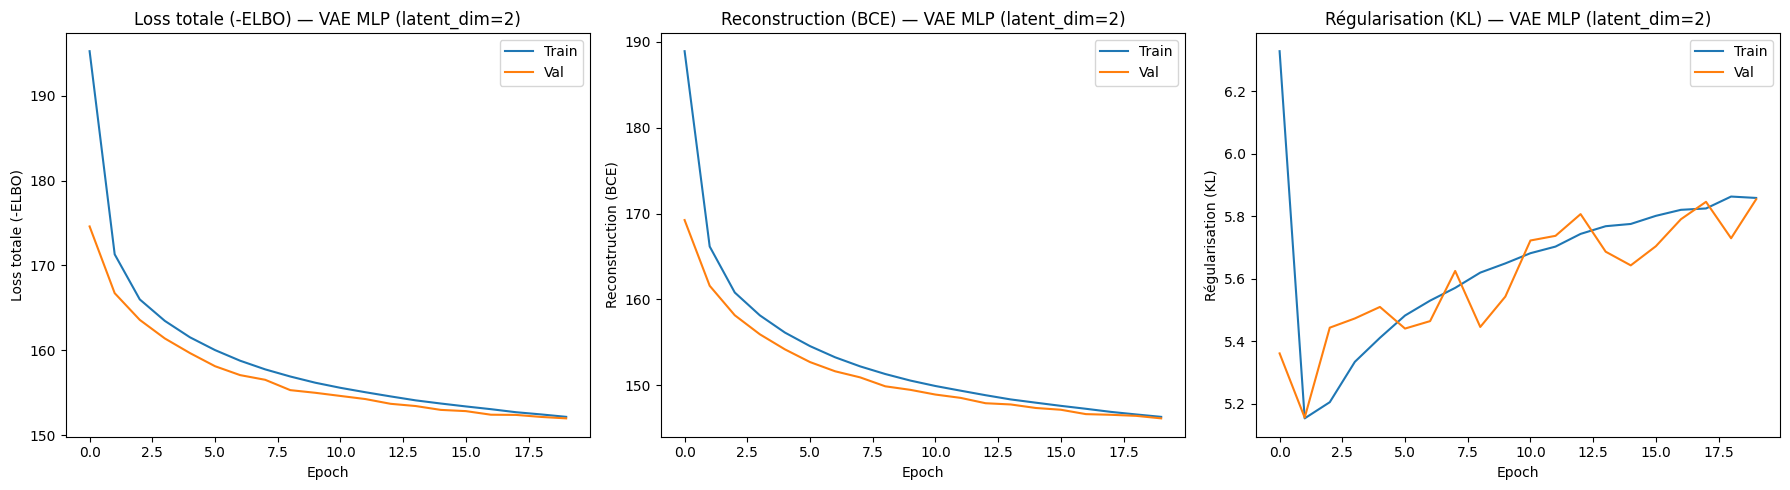

In [ ]:
# Entraînement avec espace latent de dimension 2 (visualisation directe)
latent_dim = 2
vae_mlp = VAE_MLP(latent_dim=latent_dim)
print(f"Paramètres : {sum(p.numel() for p in vae_mlp.parameters()):,}")

history_mlp = train_vae(vae_mlp, train_loader, test_loader, n_epochs=20, lr=1e-3)
plot_loss_curves(history_mlp, title=f"VAE MLP (latent_dim={latent_dim})")

## Visualisation des reconstructions

On compare les images originales (haut) et reconstruites (bas) sur le jeu de test.
Une bonne reconstruction avec un espace latent de dimension 2 est remarquable car on compresse 784 pixels en 2 nombres.

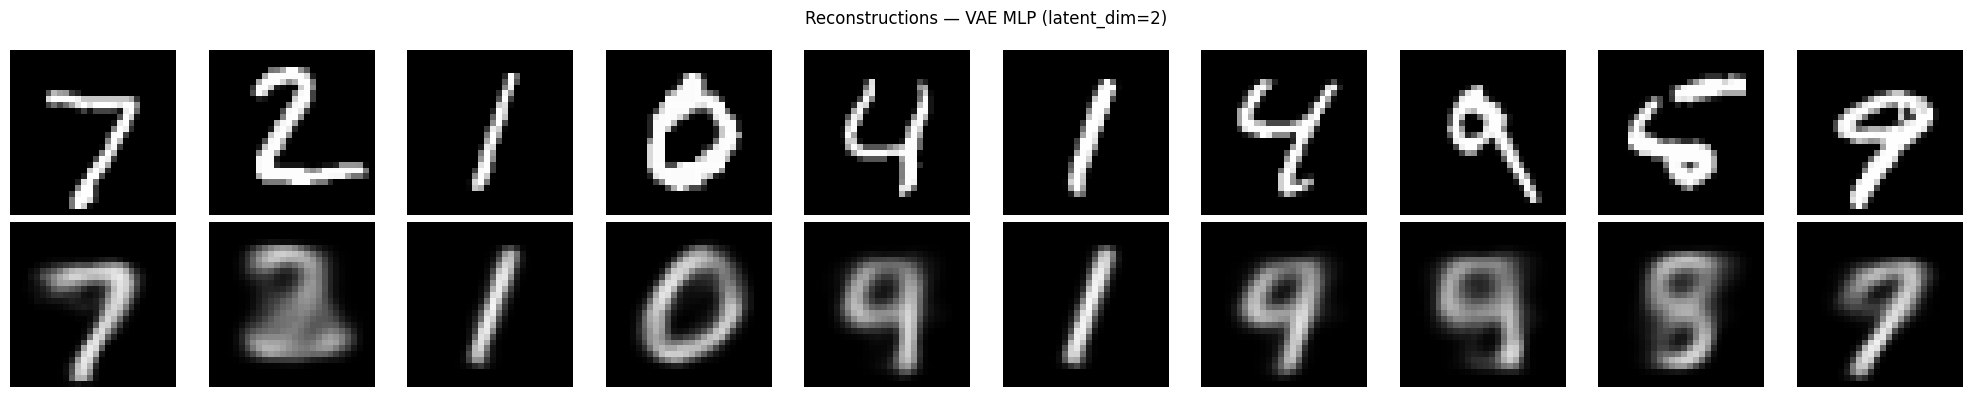

In [ ]:
def show_reconstructions(model, data_loader, n=8, title=""):
    # Affiche n images originales et leur reconstruction.
    model.eval()
    x, _ = next(iter(data_loader))
    x = x[:n].to(device)

    with torch.no_grad():
        x_hat, mu, _ = model(x)

    x_hat = x_hat.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')
        axes[1, i].imshow(x_hat[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Originales", fontsize=10)
    axes[1, 0].set_ylabel("Reconstruites", fontsize=10)
    plt.suptitle(f"Reconstructions — {title}")
    plt.tight_layout()
    plt.show()


show_reconstructions(vae_mlp, test_loader, n=10, title=f"VAE MLP (latent_dim={latent_dim})")

## Génération de nouvelles images

Pour générer, on sample directement $z \sim \mathcal{N}(0, I)$ et on décode.

**Théorie — Pourquoi la régularisation KL permet la génération :**

Sans la pénalité KL, l espace latent serait "troué" : les régions entre les codes appris pour les données d'entraînement seraient vides et produiraient des images sans sens. La KL force l espace à être continu et dense autour de l'origine, ce qui garantit qu'un $z$ aléatoire produit une image cohérente.

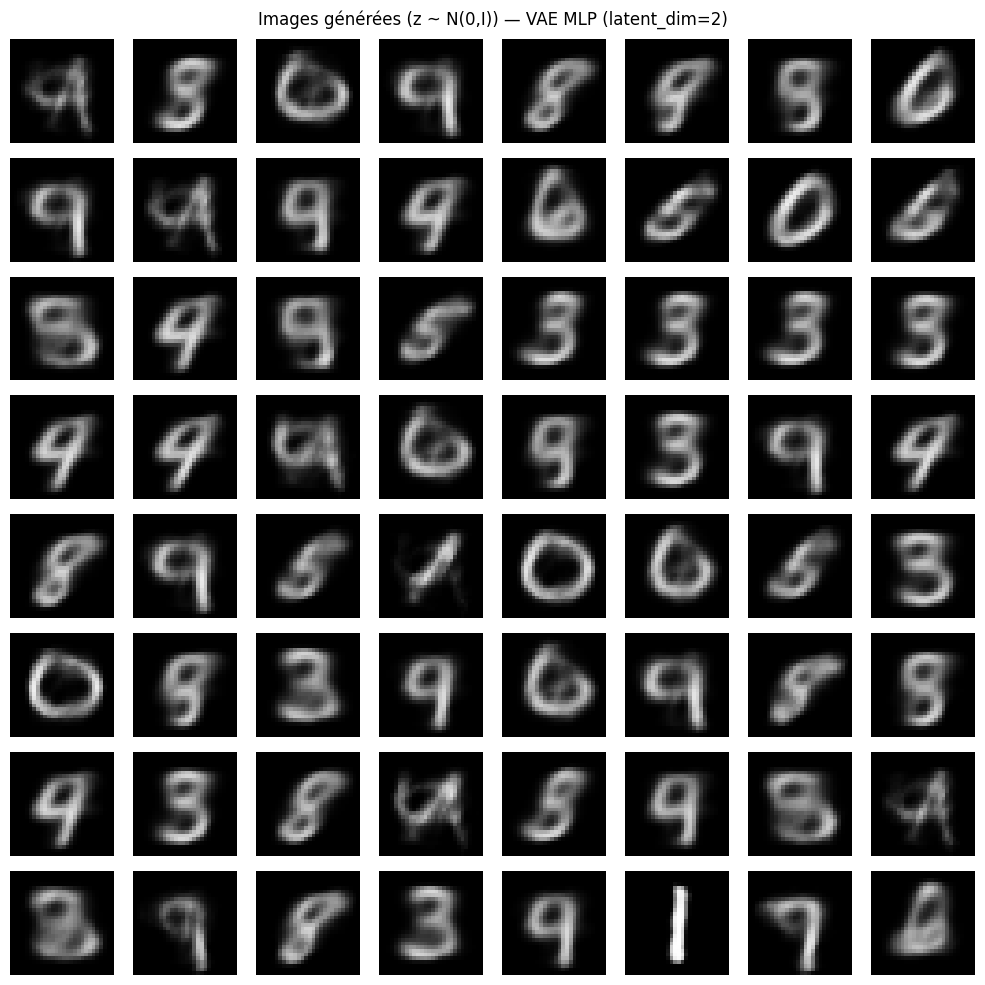

In [ ]:
def generate_samples(model, n=64, title=""):
    # Sample z ~ N(0,I) et décode pour générer de nouvelles images.
    model.eval()
    with torch.no_grad():
        # z ~ N(0, I) : distribution a priori
        z = torch.randn(n, model.latent_dim, device=device)
        x_gen = model.decode(z).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(x_gen[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.suptitle(f"Images générées (z ~ N(0,I)) — {title}")
    plt.tight_layout()
    plt.show()


generate_samples(vae_mlp, n=64, title=f"VAE MLP (latent_dim={latent_dim})")

## Visualisation de l espace latent (dim=2)

Deux visualisations complémentaires :

1. **Scatter des embeddings** colorié par classe : permet de voir si l espace latent sépare les chiffres de manière organisée. Un VAE bien entraîné montre des clusters continus pour chaque chiffre, sans séparation trop nette (grâce à la KL).

2. **Grille de génération 2D** : on balaie une grille uniforme dans l espace latent 2D et on décode chaque point. Permet d'observer la signification sémantique des axes latents (ex : axe horizontal = épaisseur du trait, axe vertical = orientation du chiffre).

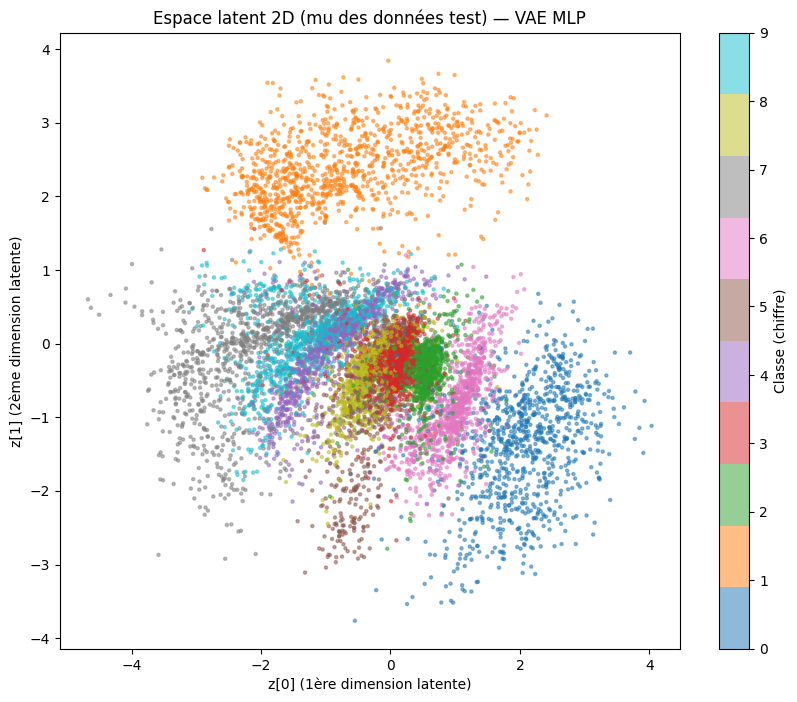

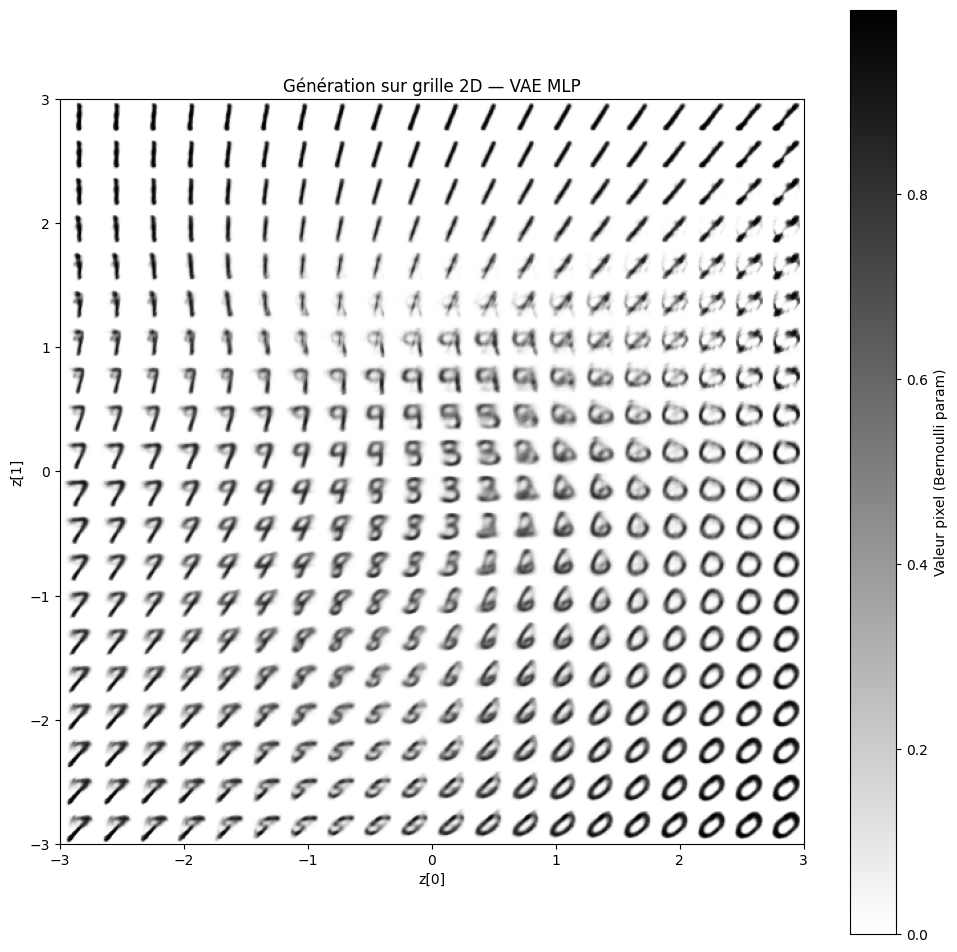

In [ ]:
def plot_latent_space(model, data_loader, title=""):
    # Encode tout le test set et visualise les mu dans l espace latent 2D.
    model.eval()
    all_mu, all_labels = [], []

    with torch.no_grad():
        for x, labels in data_loader:
            mu, _ = model.encode(x.to(device))
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    all_mu     = np.concatenate(all_mu)
    all_labels = np.concatenate(all_labels)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                          c=all_labels, cmap='tab10', alpha=0.5, s=5)
    plt.colorbar(scatter, label='Classe (chiffre)')
    plt.xlabel('z[0] (1ère dimension latente)')
    plt.ylabel('z[1] (2ème dimension latente)')
    plt.title(f"Espace latent 2D (mu des données test) — {title}")
    # Observation attendue :
    # - Clusters distincts mais chevauchants pour chaque chiffre
    # - Continuité dans les transitions : la KL empêche les "trous" entre clusters
    # - Chiffres similaires (ex: 3,5,8 ou 4,9) proches dans l espace latent
    plt.show()


def plot_latent_grid(model, grid_size=20, z_range=3.0, title=""):
    # Balaie une grille uniforme dans [-z_range, z_range]^2 et décode.
    # Permet de comprendre la sémantique de chaque dimension latente.
    model.eval()
    # Grille de points uniformément espacés dans [-z_range, z_range]
    # (plus représentatif que N(0,1) pour couvrir tout l espace visible)
    grid_x = np.linspace(-z_range, z_range, grid_size)
    grid_y = np.linspace(-z_range, z_range, grid_size)[::-1]  # y inversé pour l'affichage

    figure = np.zeros((28 * grid_size, 28 * grid_size))

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float, device=device)
                x_decoded = model.decode(z).view(28, 28).cpu().numpy()
                figure[i*28:(i+1)*28, j*28:(j+1)*28] = x_decoded

    plt.figure(figsize=(12, 12))
    plt.imshow(figure, cmap='gray_r', origin='upper',
               extent=[-z_range, z_range, -z_range, z_range])
    plt.xlabel('z[0]'); plt.ylabel('z[1]')
    plt.title(f"Génération sur grille 2D — {title}")
    plt.colorbar(label='Valeur pixel (Bernoulli param)')
    plt.show()
    # La grille révèle la structure de l espace latent :
    # - Chaque région de la grille correspond à un "style" de chiffre
    # - Les transitions sont lisses (pas de coupures) grâce à la regularisation KL
    # - Les bords (-3, 3) produisent souvent des images floues car z loin du support de N(0,I)


if latent_dim == 2:
    plot_latent_space(vae_mlp, test_loader, title="VAE MLP")
    plot_latent_grid(vae_mlp, grid_size=20, z_range=3.0, title="VAE MLP")
else:
    print(f"Visualisation 2D non disponible pour latent_dim={latent_dim}")
    print("Relancer avec latent_dim=2 pour voir l espace latent.")

## Interpolation dans l espace latent

**Théorie — Propriété de continuité :**

Une des propriétés clés du VAE : l espace latent est **continu et interpolable**. En interpolant linéairement entre les codes $z_1$ et $z_2$ de deux images :
$$z(\alpha) = (1-\alpha) z_1 + \alpha z_2, \quad \alpha \in [0, 1]$$

On obtient une transition douce entre les deux images. C'est impossible avec un AE classique (espace latent fragmenté) mais naturel avec le VAE (espace latent régularisé et dense).

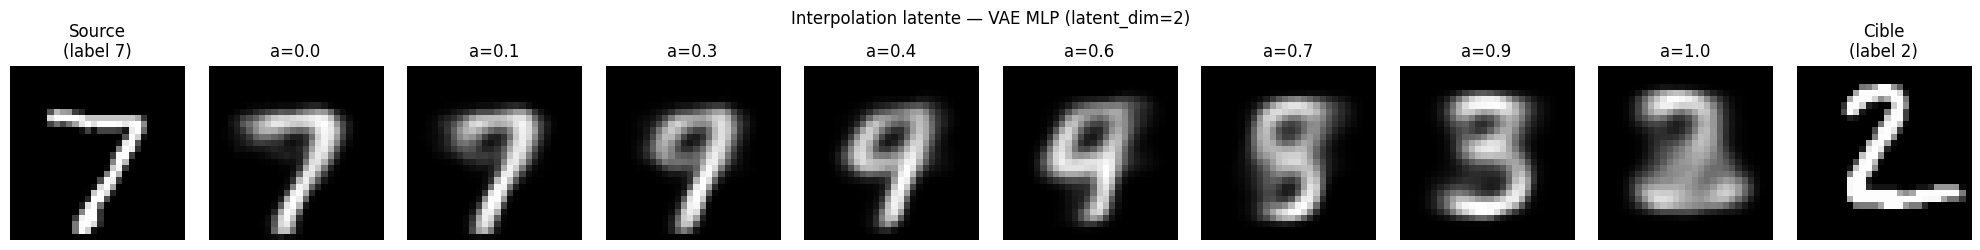

In [ ]:
def interpolate(model, data_loader, n_steps=10, title=""):
    # Interpole entre deux images aléatoires dans l espace latent.
    # Montre la continuité et la structure de l espace latent VAE.
    model.eval()
    x, labels = next(iter(data_loader))
    x = x[:2].to(device)  # deux images source et cible

    with torch.no_grad():
        mu, _ = model.encode(x)
        z1, z2 = mu[0], mu[1]  # codes latents des deux images (déterministes : mu, pas z)

        # Interpolation linéaire entre z1 et z2
        alphas = torch.linspace(0, 1, n_steps, device=device)
        z_interp = torch.stack([(1 - a) * z1 + a * z2 for a in alphas])  # (n_steps, latent_dim)

        x_interp = model.decode(z_interp).view(n_steps, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, n_steps + 2, figsize=(2*(n_steps+2), 2.5))

    # Image source
    axes[0].imshow(x[0].cpu().squeeze(), cmap='gray')
    axes[0].set_title(f"Source\n(label {labels[0].item()})")
    axes[0].axis('off')

    # Images interpolées
    for i in range(n_steps):
        axes[i+1].imshow(x_interp[i].squeeze(), cmap='gray')
        axes[i+1].set_title(f"a={alphas[i].item():.1f}")
        axes[i+1].axis('off')

    # Image cible
    axes[-1].imshow(x[1].cpu().squeeze(), cmap='gray')
    axes[-1].set_title(f"Cible\n(label {labels[1].item()})")
    axes[-1].axis('off')

    plt.suptitle(f"Interpolation latente — {title}")
    plt.tight_layout()
    plt.show()
    # Observation :
    # - Transitions douces et continues : propriété de la regularisation KL
    # - La sémantique change progressivement (ex : 3 -> 8 via des formes intermédiaires)
    # - Contraste avec un AE classique : interpolation souvent incohérente (milieu flou ou absurde)


interpolate(vae_mlp, test_loader, n_steps=8, title=f"VAE MLP (latent_dim={latent_dim})")

## Influence de la dimension de l espace latent

**Théorie — Trade-off capacité/régularisation :**

- **latent_dim petit (2)** : bottleneck fort, reconstruction approximative mais espace latent très structuré et interprétable. Génération de bonne qualité.
- **latent_dim grand (64, 128)** : reconstruction quasi-parfaite mais risque que la KL soit "négligée" (l encodeur utilise une petite portion de l espace, le reste est inutilisé — problème dit de "posterior collapse").

=== Entraînement VAE MLP latent_dim=2 ===


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   1/15 | train loss=196.8  recon=190.3  kl=6.56 | val loss=173.9  recon=168.3  kl=5.66


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   2/15 | train loss=171.3  recon=165.9  kl=5.42 | val loss=166.5  recon=161.1  kl=5.46


...

Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  14/15 | train loss=154.1  recon=148.3  kl=5.81 | val loss=153.2  recon=147.5  kl=5.68


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>^^
Traceback (most recent call last):

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        assert self._parent_pid == os.getpid(), 'can only test a child process'
self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():   
         ^ ^ ^^^^^^^^^^^^^^^^^^^^^^^

Epoch  15/15 | train loss=153.7  recon=147.9  kl=5.82 | val loss=153.0  recon=147.2  kl=5.77


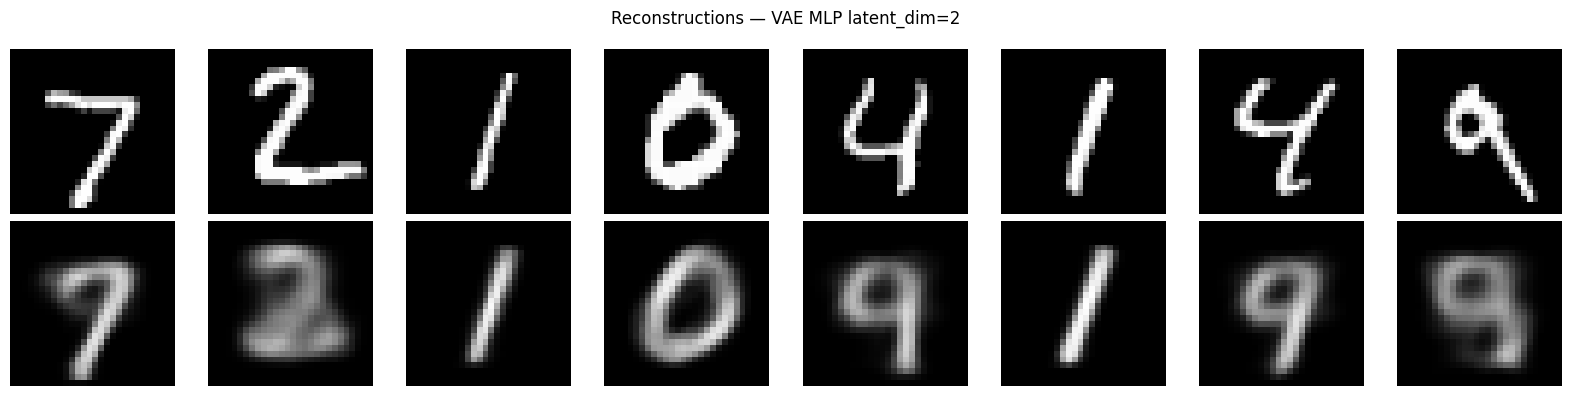

=== Entraînement VAE MLP latent_dim=8 ===


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():
  
          ^ ^ ^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

Epoch   1/15 | train loss=170.8  recon=157.7  kl=13.07 | val loss=132.6  recon=117.4  kl=15.20


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>    
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():self._shutdown_workers()
  
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): ^
^ ^ ^  ^^ ^  ^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^ 
    File "/usr/lib/py

Epoch  14/15 | train loss=115.0  recon=99.1  kl=15.94 | val loss=110.6  recon=94.2  kl=16.47


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x78eed58707c0>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()        
self._shutdown_workers()self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers


  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  F

Epoch  15/15 | train loss=114.7  recon=98.7  kl=15.97 | val loss=109.9  recon=93.9  kl=15.98


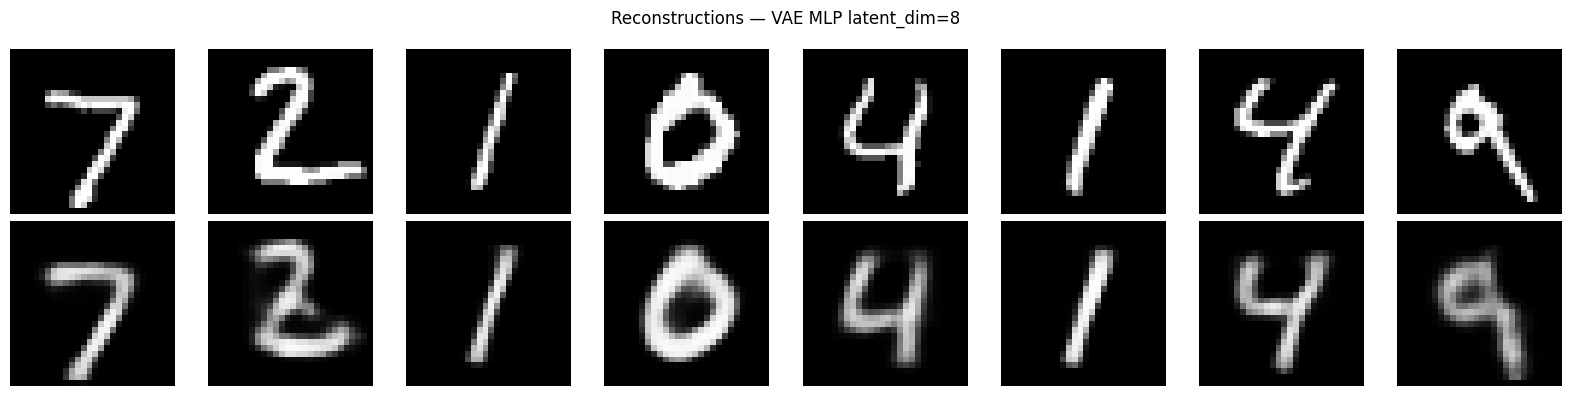

=== Entraînement VAE MLP latent_dim=32 ===


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   1/15 | train loss=176.5  recon=161.2  kl=15.25 | val loss=129.5  recon=109.1  kl=20.39


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   2/15 | train loss=129.1  recon=107.7  kl=21.41 | val loss=111.5  recon=88.7  kl=22.76


...

Epoch  13/15 | train loss=106.8  recon=80.6  kl=26.18 | val loss=95.9  recon=70.1  kl=25.81


Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  14/15 | train loss=106.5  recon=80.3  kl=26.20 | val loss=95.9  recon=69.9  kl=25.98


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  15/15 | train loss=106.2  recon=80.0  kl=26.21 | val loss=95.6  recon=69.6  kl=25.97


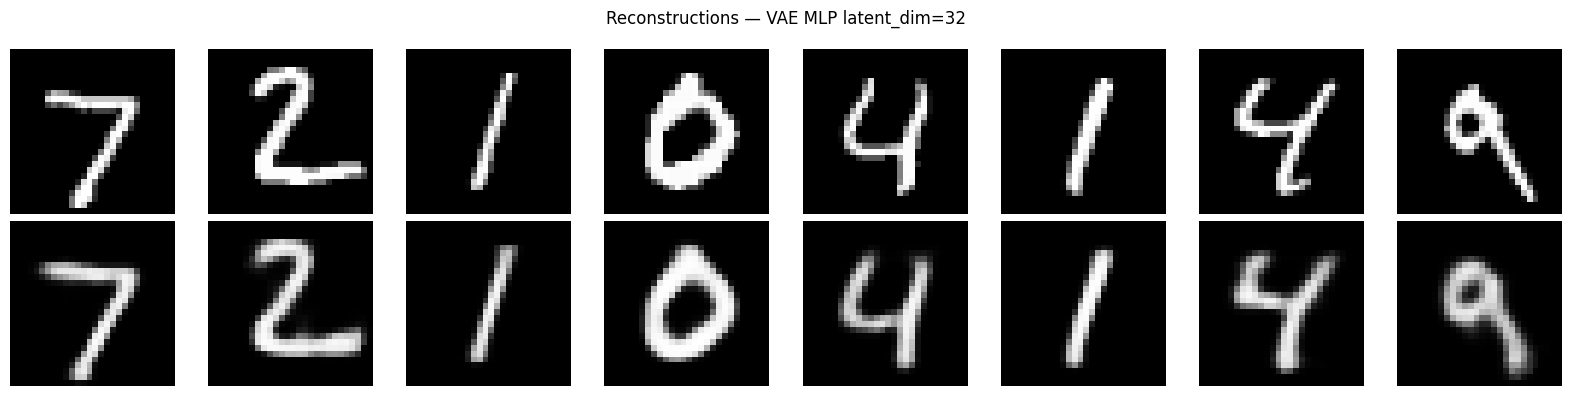

=== Comparaison des loss finales (val) ===
  latent_dim |     loss |    recon |       kl
---------------------------------------------
           2 |    153.0 |    147.2 |     5.77
           8 |    109.9 |     93.9 |    15.98
          32 |     95.6 |     69.6 |    25.97


In [ ]:
# Comparaison de plusieurs dimensions latentes
latent_dims_to_test = [2, 8, 32]
results = {}

for ld in latent_dims_to_test:
    print(f"=== Entraînement VAE MLP latent_dim={ld} ===")
    model_ld = VAE_MLP(latent_dim=ld).to(device)
    history_ld = train_vae(model_ld, train_loader, test_loader, n_epochs=15, lr=1e-3)
    results[ld] = {'model': model_ld, 'history': history_ld}
    show_reconstructions(model_ld, test_loader, n=8, title=f"VAE MLP latent_dim={ld}")

# Comparaison des loss finales
print("=== Comparaison des loss finales (val) ===")
print(f"{'latent_dim':>12} | {'loss':>8} | {'recon':>8} | {'kl':>8}")
print("-" * 45)
for ld, res in results.items():
    h = res['history']
    print(f"{ld:>12} | {h['val_loss'][-1]:>8.1f} | {h['val_recon'][-1]:>8.1f} | {h['val_kl'][-1]:>8.2f}")
# Observation attendue :
# latent_dim plus grand -> reconstruction BCE plus faible (meilleure fidélité)
# latent_dim plus grand -> KL plus grande (plus d'information encodée)
# La reconstruction parfaite avec latent_dim=784 serait triviale (copier x dans z)

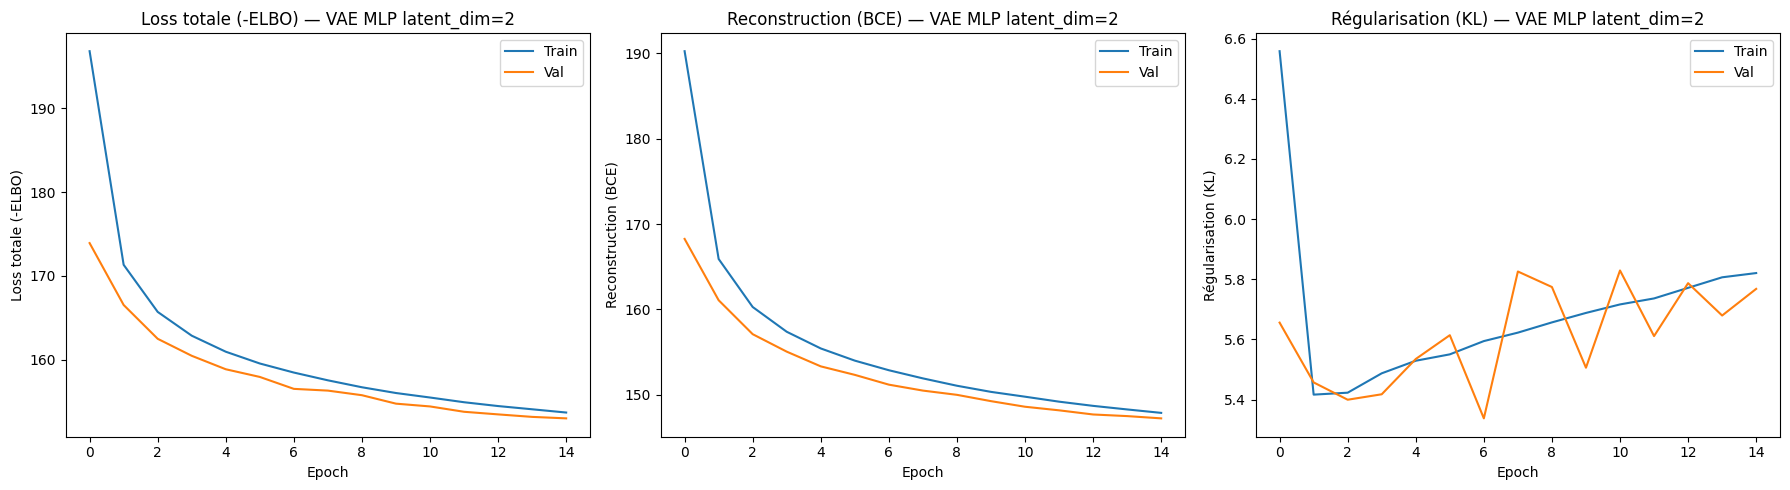

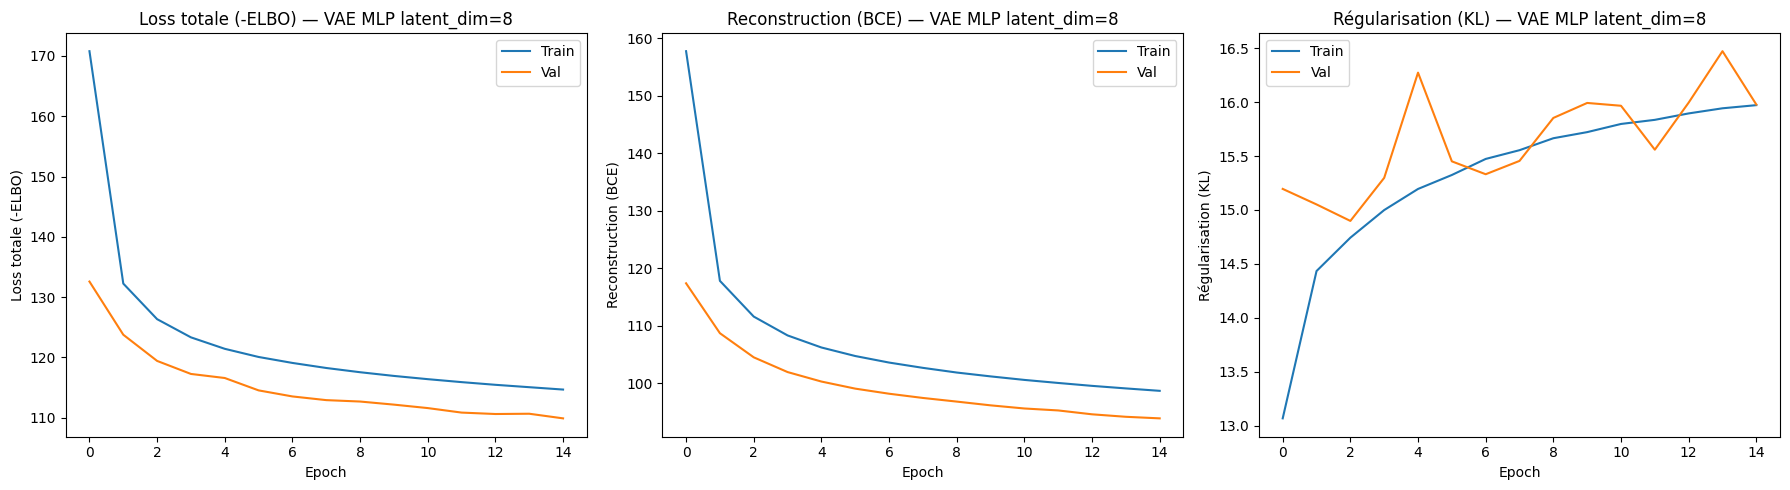

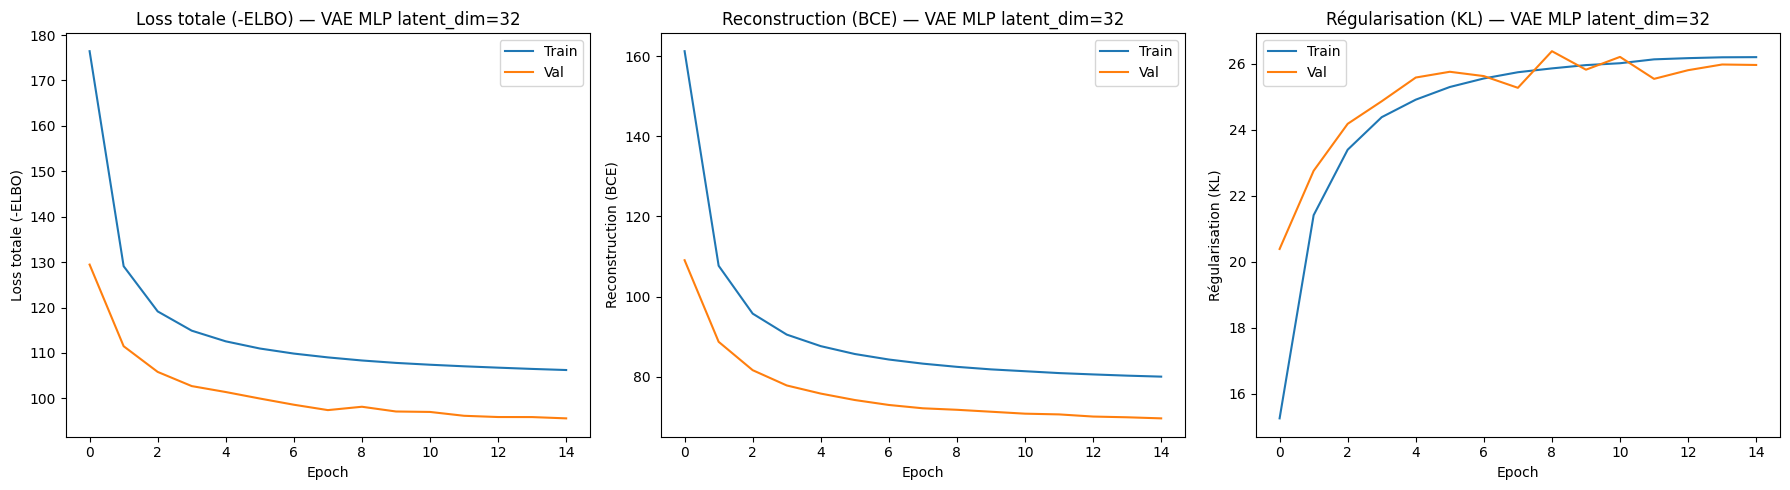

In [ ]:
# plot train loss kl recon :
for ld, res in results.items():
    h = res['history']
    plot_loss_curves(h, title=f"VAE MLP latent_dim={ld}")


## Partie 2 : VAE avec architecture CNN

**Théorie — Avantages des convolutions pour les images :**

Les couches fully-connected traitent chaque pixel indépendamment (784 entrées). Les convolutions exploitent la **structure spatiale locale** des images :
- **Partage de poids** : le même filtre est appliqué à toute l'image -> translation-invariance, moins de paramètres
- **Hiérarchie de features** : premières couches = bords/textures, couches profondes = formes/structures
- **Efficacité** : moins de paramètres qu'un MLP pour le même niveau de performance

**Architecture :**

Encodeur : Conv(1->32, k=3, s=2) -> ReLU -> Conv(32->64, k=3, s=2) -> ReLU -> Flatten -> Linear -> (mu, logsigma)
Décodeur : Linear -> Reshape -> ConvTranspose(64->32, k=3, s=2) -> ReLU -> ConvTranspose(32->1, k=3, s=2) -> Sigmoid

Les ConvTranspose2d (déconvolutions) inversent les convolutions strided pour remonter à 28x28.

In [ ]:
class VAE_CNN(nn.Module):
    def __init__(self, latent_dim=32):
        # VAE avec encodeur/décodeur convolutionnels.
        # Plus adapté aux images que le MLP : exploite la structure spatiale locale.
        super(VAE_CNN, self).__init__()
        self.latent_dim = latent_dim

        # ── Encodeur convolutionnel ────────────────────────────────────────
        # Extraction de features locales par convolutions strided
        # Conv2d(in_ch, out_ch, kernel, stride, padding)
        # H_out = floor((H_in + 2*p - k) / s) + 1
        # 28x28 -> 13x13 (avec k=3, s=2, p=0) -> 6x6 (k=3, s=2, p=0)
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=0)
        # H_out = floor((28 - 3) / 2) + 1 = 13
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=0)
        # H_out = floor((13 - 3) / 2) + 1 = 6
        # Après flatten : 64 * 6 * 6 = 2304

        self.enc_fc = nn.Linear(64 * 6 * 6, 2 * latent_dim)

        # ── Décodeur convolutionnel ────────────────────────────────────────
        self.dec_fc = nn.Linear(latent_dim, 64 * 6 * 6)

        # ConvTranspose2d : inverse de Conv2d (upsampling)
        # H_out = (H_in - 1) * stride - 2*padding + kernel + output_padding
        # 6 -> 13 (k=3, s=2, p=0, op=1) : H = (6-1)*2 - 0 + 3 + 1 = 14 -> on veut 13
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=0, output_padding=0)
        # H = (6-1)*2 + 3 = 13 -> OK
        # 13 -> 28 (k=3, s=2, p=0, op=1) : H = (13-1)*2 + 3 + 1 = 28 -> OK
        self.dec_conv2 = nn.ConvTranspose2d(32, 1,  kernel_size=3, stride=2, padding=0, output_padding=1)

    def encode(self, x):
        # x : (batch, 1, 28, 28)
        h = F.relu(self.enc_conv1(x))         # (batch, 32, 13, 13)
        h = F.relu(self.enc_conv2(h))          # (batch, 64, 6, 6)
        h = h.view(h.size(0), -1)              # (batch, 64*6*6 = 2304)
        out = self.enc_fc(h)                   # (batch, 2*latent_dim)
        mu       = out[:, :self.latent_dim]
        logsigma = out[:, self.latent_dim:]
        return mu, logsigma

    def reparametrize(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            epsilon = torch.randn_like(std)
            return mu + std * epsilon
        else:
            return mu

    def decode(self, z):
        # z : (batch, latent_dim)
        h = F.relu(self.dec_fc(z))             # (batch, 2304)
        h = h.view(h.size(0), 64, 6, 6)        # (batch, 64, 6, 6)
        h = F.relu(self.dec_conv1(h))           # (batch, 32, 13, 13)
        x_hat = torch.sigmoid(self.dec_conv2(h))  # (batch, 1, 28, 28) dans [0,1]
        return x_hat

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z     = self.reparametrize(mu, logsigma)
        x_hat = self.decode(z)
        return x_hat, mu, logsigma


def vae_loss_cnn(x, x_hat, mu, logsigma):
    # Loss VAE pour le modèle CNN.
    # x_hat est ici (batch, 1, 28, 28) au lieu de (batch, 784).
    # On utilise reduction='sum' et on normalise par batch_size.
    batch_size = x.size(0)
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return (recon_loss + kl_loss) / batch_size, recon_loss / batch_size, kl_loss / batch_size


# Verification des dimensions
model_cnn_test = VAE_CNN(latent_dim=32)
x_test = torch.randn(4, 1, 28, 28)
x_hat, mu, ls = model_cnn_test(x_test)
print(f"x     : {tuple(x_test.shape)}")
print(f"x_hat : {tuple(x_hat.shape)}")
print(f"mu    : {tuple(mu.shape)}")
assert x_hat.shape == (4, 1, 28, 28), f"Taille incorrecte: {x_hat.shape}"
print("Dimensions OK")
print(f"Paramètres CNN : {sum(p.numel() for p in model_cnn_test.parameters()):,}")

x     : (4, 1, 28, 28)
x_hat : (4, 1, 28, 28)
mu    : (4, 32)
Dimensions OK
Paramètres CNN : 261,121


In [ ]:
def train_vae_cnn(model, train_loader, test_loader, n_epochs=20, lr=1e-3):
    optimizer = Adam(model.parameters(), lr=lr)
    model = model.to(device)
    history = {'train_loss':[], 'val_loss':[], 'train_recon':[], 'val_recon':[], 'train_kl':[], 'val_kl':[]}

    for epoch in range(n_epochs):
        model.train()
        total_loss = total_recon = total_kl = 0.0

        for x, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False):
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, logsigma = model(x)
            loss, recon, kl = vae_loss_cnn(x, x_hat, mu, logsigma)
            loss.backward()
            optimizer.step()
            total_loss  += loss.item()
            total_recon += recon.item()
            total_kl    += kl.item()

        n = len(train_loader)
        history['train_loss'].append(total_loss / n)
        history['train_recon'].append(total_recon / n)
        history['train_kl'].append(total_kl / n)

        model.eval()
        total_loss = total_recon = total_kl = 0.0

        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                x_hat, mu, logsigma = model(x)
                loss, recon, kl = vae_loss_cnn(x, x_hat, mu, logsigma)
                total_loss  += loss.item()
                total_recon += recon.item()
                total_kl    += kl.item()

        n = len(test_loader)
        history['val_loss'].append(total_loss / n)
        history['val_recon'].append(total_recon / n)
        history['val_kl'].append(total_kl / n)

        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"train loss={history['train_loss'][-1]:.1f}  recon={history['train_recon'][-1]:.1f}  kl={history['train_kl'][-1]:.2f} | "
              f"val loss={history['val_loss'][-1]:.1f}  recon={history['val_recon'][-1]:.1f}  kl={history['val_kl'][-1]:.2f}")

    return history


vae_cnn = VAE_CNN(latent_dim=32)
history_cnn = train_vae_cnn(vae_cnn, train_loader, test_loader, n_epochs=20, lr=1e-3)
plot_loss_curves(history_cnn, title="VAE CNN (latent_dim=32)")

In [ ]:
# Comparaison MLP vs CNN
show_reconstructions(vae_cnn, test_loader, n=10, title="VAE CNN (latent_dim=32)")
generate_samples(vae_cnn, n=64, title="VAE CNN (latent_dim=32)")
interpolate(vae_cnn, test_loader, n_steps=8, title="VAE CNN (latent_dim=32)")

# Comparaison des perfs finales
print("
=== MLP (dim=2) vs CNN (dim=32) — val loss finale ===")
print(f"MLP : recon={history_mlp['val_recon'][-1]:.1f}  kl={history_mlp['val_kl'][-1]:.2f}")
print(f"CNN : recon={history_cnn['val_recon'][-1]:.1f}  kl={history_cnn['val_kl'][-1]:.2f}")

---
## Questions d oral probables

### Sur le modèle VAE et ses fondements théoriques

**Q : Quelle est la différence entre un auto-encodeur classique et un VAE ?**
Un AE classique mappe chaque $x$ vers un vecteur latent **déterministe** $z = g(x)$. L'espace latent est non régularisé : des régions arbitraires peuvent être vides ou incohérentes. Un VAE mappe $x$ vers une **distribution** $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2 I)$. La KL force cette distribution à rester proche de $\mathcal{N}(0,I)$ -> espace latent continu, dense, utilisable pour la génération.

**Q : Qu'est-ce que l ELBO et pourquoi le maximise-t-on ?**
La log-vraisemblance $\log p_\theta(x) = \log \int p_\theta(x|z) p(z) dz$ est intractable (intégrale sur tout l espace latent). L'ELBO est une borne inférieure : $\log p_\theta(x) \geq \mathbb{E}_{q_\phi}[\log p_\theta(x|z)] - KL(q_\phi \| p)$. En maximisant l ELBO, on maximise simultanément la reconstruction et on contraint $q_\phi$ à rester proche de la prior $p(z)$.

**Q : Expliquer le reparametrization trick.**
Le tirage $z \sim \mathcal{N}(\mu, \sigma^2)$ est non-différentiable par rapport à $\mu$ et $\sigma$ car le tirage lui-même dépend des paramètres. On réécrit $z = \mu + \sigma \odot \epsilon$ avec $\epsilon \sim \mathcal{N}(0,I)$ tiré indépendamment. Le bruit $\epsilon$ est non-paramétrisé -> les gradients $\partial \mathcal{L}/\partial \mu$ et $\partial \mathcal{L}/\partial \sigma$ sont calculables par backprop standard.

**Q : Pourquoi paramétrise-t-on logsigma au lieu de sigma ?**
$\sigma^2 > 0$ toujours, mais un réseau peut produire n importe quelle valeur réelle. En prédisant $\log(\sigma^2) \in \mathbb{R}$, pas de contrainte de positivité. De plus, $\exp(\text{logsigma})$ est numériquement plus stable que des valeurs de $\sigma$ très proches de 0 (qui créeraient des $1/\sigma$ énormes dans le gradient).

**Q : Donner la formule de la KL analytique entre $\mathcal{N}(\mu, \text{diag}(\sigma^2))$ et $\mathcal{N}(0,I)$.**
$$KL = -\frac{1}{2} \sum_{i=1}^{d} (1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2) = -\frac{1}{2} \sum_{i=1}^{d} (1 + \text{logsigma}_i - \mu_i^2 - e^{\text{logsigma}_i})$$
Cette formule est obtenue par calcul direct entre deux gaussiennes (voir dérivation dans les notes de cours).

### Sur l'architecture et l entrainement

**Q : Pourquoi utilise-t-on une BCE comme terme de reconstruction ?**
La BCE correspond à la log-vraisemblance d un modèle Bernoulli par pixel : $-\log p(x|z) = \text{BCE}(x, \hat{x})$ quand $\hat{x}_j = p(\text{pixel}_j = 1 | z)$. Si on utilisait un décodeur gaussien, on utiliserait la MSE (qui correspond à une vraisemblance gaussienne).

**Q : Quel est l'effet d un espace latent de très grande dimension ?**
Risque de "posterior collapse" : le modèle peut ignorer la dimension latente et tout mettre dans le décodeur (qui reconstruit parfaitement sans avoir besoin de z). Le KL devient alors proche de 0 pour certaines dimensions -> elles ne sont plus utilisées. Solution : annealing KL (augmenter progressivement le poids de la KL).

**Q : VAE vs GAN : avantages et inconvénients ?**
- VAE : entraînement stable, ELBO bien défini, espace latent interprétable, mais reconstructions parfois floues (BCE/MSE moyennent sur l incertitude).
- GAN : images plus nettes/réalistes, mais entraînement instable (mode collapse, non-convergence), pas d'encodeur (pas de compression), évaluation difficile.

**Q : Qu'est-ce que le "posterior collapse" dans les VAEs ?**
Le décodeur devient si puissant qu il ignore z : $q_\phi(z|x) \approx p(z)$ pour tout x (KL -> 0) et le décodeur reconstruit x sans information de z. Cela arrive surtout avec des décodeurs autorégressifs très puissants ou des espaces latents de grande dimension. Solutions : KL annealing, free bits, architecture moins puissante du décodeur.